**FASE 4a: ENTRENAMIENTO DE REDES EXPERTAS INDEPENDIENTES (CEW y YawDD)**

Autor: Andoni Cabrera Fernández

Descripción: En este cuaderno se materializa el "Desacoplamiento Espacial". En lugar de forzar a una sola red a procesar el rostro completo o un tensor híbrido, se entrenan dos modelos MobileNetV2 independientes:
1. Experto en Ojos: Entrenado con el dataset CEW (Closed Eyes in the Wild) para detectar parpadeo y cierre ocular prolongado (EAR).
2. Experto en Boca: Entrenado con el dataset YawDD (Yawning Detection Dataset) para detectar bostezos (MAR).

Se aplica "Fine-Tuning" (Ajuste Fino) profundo, descongelando los últimos bloques de la base convolucional para adaptar los filtros a estas micro-regiones específicas.

**1. IMPORTACIÓN E INFRAESTRUCTURA**

In [1]:
from google.colab import drive
import os
import shutil
import pandas as pd
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

# 1. Montar Google Drive
drive.mount('/content/drive')

# 2. Definición de rutas principales
ruta_zip_ddd = '/content/drive/MyDrive/TFG_Fatiga_Colab/DDD_Dataset.zip'
ruta_extraccion_local = '/content/dataset_rois'

ruta_cew_local = '/content/dataset_ojos'
ruta_yawdd_local = '/content/dataset_boca'

# 3. Descompresión en local
if not os.path.exists(ruta_extraccion_local):
    print("Descomprimiendo DDD_Dataset.zip...")
    !unzip -q "{ruta_zip_ddd}" -d "{ruta_extraccion_local}"
    print("¡Descompresión completada!")

# 4. REORGANIZACIÓN INTELIGENTE (Separar Ojos y Bocas)
ruta_mezclada = os.path.join(ruta_extraccion_local, 'train')

if os.path.exists(ruta_mezclada):
    print("Organizando las clases en datasets independientes...")
    os.makedirs(ruta_cew_local, exist_ok=True)
    os.makedirs(ruta_yawdd_local, exist_ok=True)

    # Movemos los Ojos a su carpeta
    if os.path.exists(os.path.join(ruta_mezclada, 'Open')):
        shutil.move(os.path.join(ruta_mezclada, 'Open'), os.path.join(ruta_cew_local, 'Open'))
    if os.path.exists(os.path.join(ruta_mezclada, 'Closed')):
        shutil.move(os.path.join(ruta_mezclada, 'Closed'), os.path.join(ruta_cew_local, 'Closed'))

    # Movemos las Bocas a su carpeta
    if os.path.exists(os.path.join(ruta_mezclada, 'yawn')):
        shutil.move(os.path.join(ruta_mezclada, 'yawn'), os.path.join(ruta_yawdd_local, 'yawn'))
    if os.path.exists(os.path.join(ruta_mezclada, 'no_yawn')):
        shutil.move(os.path.join(ruta_mezclada, 'no_yawn'), os.path.join(ruta_yawdd_local, 'no_yawn'))

    print("¡Datasets de Ojos y Boca separados correctamente!")
else:
    print("Los datasets ya estaban organizados en la memoria temporal.")

Mounted at /content/drive
Descomprimiendo DDD_Dataset.zip...
¡Descompresión completada!
Organizando las clases en datasets independientes...
¡Datasets de Ojos y Boca separados correctamente!


**2. CONFIGURACIÓN DE GENERADORES Y DATA AUGMENTATION**

In [2]:
def crear_dataframe(ruta_dataset):
    """Convierte la estructura de carpetas en un DataFrame para usar scikit-learn"""
    rutas = []
    etiquetas = []
    for clase in os.listdir(ruta_dataset):
        ruta_clase = os.path.join(ruta_dataset, clase)
        if os.path.isdir(ruta_clase):
            for img in os.listdir(ruta_clase):
                if img.lower().endswith(('.png', '.jpg', '.jpeg')):
                    rutas.append(os.path.join(ruta_clase, img))
                    etiquetas.append(clase)
    return pd.DataFrame({'ruta': rutas, 'clase': etiquetas})

# 1. Crear DataFrames
df_ojos = crear_dataframe(ruta_cew_local)
df_boca = crear_dataframe(ruta_yawdd_local)

# 2. PARTICIÓN ESTRATIFICADA (70% Train / 30% Val según Alajlan e Ibrahim, 2023)
# Se fija random_state=40 para asegurar la reproducibilidad del experimento.
train_ojos, val_ojos = train_test_split(df_ojos, test_size=0.3, random_state=40, stratify=df_ojos['clase'])
train_boca, val_boca = train_test_split(df_boca, test_size=0.3, random_state=40, stratify=df_boca['clase'])

print(f"Ojos -> Train: {len(train_ojos)} | Val: {len(val_ojos)}")
print(f"Boca -> Train: {len(train_boca)} | Val: {len(val_boca)}\n")

# 3. Data Augmentation optimizado
datagen_train = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    brightness_range=[0.6, 1.4],
    horizontal_flip=True,
    fill_mode='nearest'
)

# IMPORTANTE: La validación NO lleva Data Augmentation, solo preprocesado
datagen_val = ImageDataGenerator(preprocessing_function=preprocess_input)

# 4. Generadores usando flow_from_dataframe
print("--- GENERADORES: EXPERTO EN OJOS ---")
gen_ojos_train = datagen_train.flow_from_dataframe(
    dataframe=train_ojos, x_col='ruta', y_col='clase',
    target_size=(224, 224), batch_size=32, class_mode='categorical'
)
gen_ojos_val = datagen_val.flow_from_dataframe(
    dataframe=val_ojos, x_col='ruta', y_col='clase',
    target_size=(224, 224), batch_size=32, class_mode='categorical', shuffle=False
)

print("\n--- GENERADORES: EXPERTO EN BOCA ---")
gen_boca_train = datagen_train.flow_from_dataframe(
    dataframe=train_boca, x_col='ruta', y_col='clase',
    target_size=(224, 224), batch_size=32, class_mode='categorical'
)
gen_boca_val = datagen_val.flow_from_dataframe(
    dataframe=val_boca, x_col='ruta', y_col='clase',
    target_size=(224, 224), batch_size=32, class_mode='categorical', shuffle=False
)

Ojos -> Train: 1016 | Val: 436
Boca -> Train: 1013 | Val: 435

--- GENERADORES: EXPERTO EN OJOS ---
Found 1016 validated image filenames belonging to 2 classes.
Found 436 validated image filenames belonging to 2 classes.

--- GENERADORES: EXPERTO EN BOCA ---
Found 1013 validated image filenames belonging to 2 classes.
Found 435 validated image filenames belonging to 2 classes.


**3. CONSTRUCCIÓN DE LA ARQUITECTURA BASE (CON FINE-TUNING)**

In [3]:
def construir_modelo_experto(num_clases):
    """
    Construye el modelo MobileNetV2 calcado a Alajlan e Ibrahim (2023).
    """
    # 1. Base pre-entrenada con Alpha=0.75 (Acorde al paper)
    base_model = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3),
        alpha=0.75
    )

    # 2. BLOQUEO TOTAL DE LA RED BASE ("The trainable parameters of the model are False")
    base_model.trainable = False

    # 3. Arquitectura idéntica a la Tabla 5 del paper (Sin Dropout)
    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dense(num_clases, activation='softmax')
    ])

    # 4. Optimizador Adam calcado a la Tabla 7 del paper
    model.compile(
        optimizer=Adam(
            learning_rate=0.001,
            beta_1=0.9,
            beta_2=0.999,
            epsilon=1e-7,
            amsgrad=True
        ),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

def obtener_callbacks_nuevos():
    """Genera instancias nuevas de callbacks para evitar el bug de estado de Keras"""
    return [
        EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)
    ]

**4. ENTRENAMIENTO: RED EXPERTA EN OJOS (CEW)**

In [4]:
print("Iniciando entrenamiento del Experto en OJOS...")
modelo_ojos = construir_modelo_experto(num_clases=len(gen_ojos_train.class_indices))

historial_ojos = modelo_ojos.fit(
    gen_ojos_train,
    validation_data=gen_ojos_val,
    epochs=200,
    callbacks=obtener_callbacks_nuevos()
)

# Guardar el modelo en formato Keras nativo
modelo_ojos.save('/content/experto_ojos.keras')

Iniciando entrenamiento del Experto en OJOS...
5903360/5903360 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 94s 3s/step - accuracy: 0.8819 - loss: 0.2913 - val_accuracy: 0.9518 - val_loss: 0.1330 - learning_rate: 0.0010
Epoch 2/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 75s 2s/step - accuracy: 0.9774 - loss: 0.0831 - val_accuracy: 0.9817 - val_loss: 0.0713 - learning_rate: 0.0010
Epoch 3/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - accuracy: 0.9793 - loss: 0.0604 - val_accuracy: 0.9862 - val_loss: 0.0590 - learning_rate: 0.0010
Epoch 4/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 74s 2s/step - accuracy: 0.9872 - loss: 0.0467 - val_accuracy: 0.9794 - val_loss: 0.0539 - learning_rate: 0.0010
Epoch 5/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 71s 2s/step - accuracy: 0.9823 - loss: 0.0503 - val_accuracy: 0.9862 - val_loss: 0.0423 - learning_rate: 0.0010
Epoch 6/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 74s 2s/step - accuracy: 0.9921 - loss: 0.0362 - val_accuracy: 0.9817 - val_loss: 0.0417 - learning_rate: 0.001

**5. ENTRENAMIENTO: RED EXPERTA EN BOCA (YawDD)**

In [5]:
print("\nIniciando entrenamiento del Experto en BOCA...")
modelo_boca = construir_modelo_experto(num_clases=len(gen_boca_train.class_indices))

historial_boca = modelo_boca.fit(
    gen_boca_train,
    validation_data=gen_boca_val,
    epochs=200,
    callbacks=obtener_callbacks_nuevos()
)

# Guardar el modelo en formato Keras nativo
modelo_boca.save('/content/experto_boca.keras')


Iniciando entrenamiento del Experto en BOCA...
Epoch 1/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.5982 - loss: 0.6835 - val_accuracy: 0.6736 - val_loss: 0.5736 - learning_rate: 0.0010
Epoch 2/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 75s 2s/step - accuracy: 0.6881 - loss: 0.5582 - val_accuracy: 0.7218 - val_loss: 0.5412 - learning_rate: 0.0010
Epoch 3/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 76s 2s/step - accuracy: 0.7167 - loss: 0.5223 - val_accuracy: 0.7126 - val_loss: 0.4987 - learning_rate: 0.0010
Epoch 4/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 72s 2s/step - accuracy: 0.7275 - loss: 0.4984 - val_accuracy: 0.7310 - val_loss: 0.5109 - learning_rate: 0.0010
Epoch 5/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 75s 2s/step - accuracy: 0.7868 - loss: 0.4477 - val_accuracy: 0.7540 - val_loss: 0.4722 - learning_rate: 0.0010
Epoch 6/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 76s 2s/step - accuracy: 0.7848 - loss: 0.4584 - val_accuracy: 0.7494 - val_loss: 0.4612 - learning_rate: 0.0010
Epoch 7/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 72s 2s/

**6. EVALUACIÓN Y EXPORTACIÓN DE LOS MODELOS FINALES**

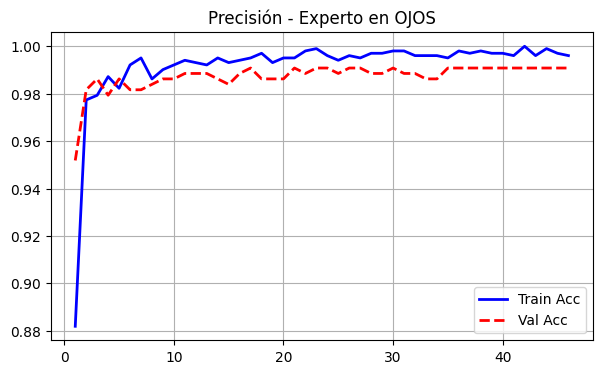

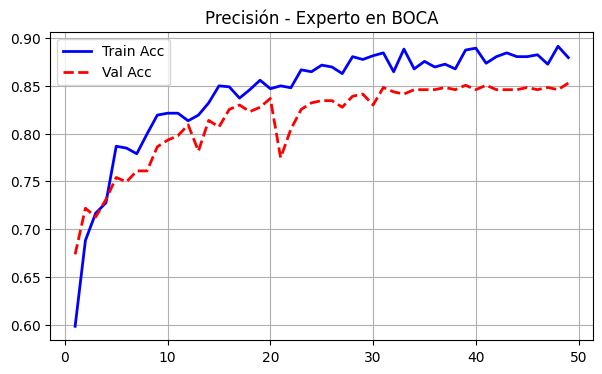


Modelos expertos entrenados y guardados en: /content/drive/MyDrive/TFG_Fatiga_Colab/Modelos_Fase4


In [6]:
def plot_historial(historial, titulo):
    acc = historial.history['accuracy']
    val_acc = historial.history['val_accuracy']
    epocas = range(1, len(acc) + 1)

    plt.figure(figsize=(7, 4))
    plt.plot(epocas, acc, 'b-', label='Train Acc', linewidth=2)
    plt.plot(epocas, val_acc, 'r--', label='Val Acc', linewidth=2)
    plt.title(titulo)
    plt.legend(); plt.grid(True)
    plt.show()

# Mostrar gráficas de convergencia
plot_historial(historial_ojos, 'Precisión - Experto en OJOS')
plot_historial(historial_boca, 'Precisión - Experto en BOCA')

# Exportar al Drive para la Fase 4b (Cuantización TFLite)
ruta_drive_modelos = '/content/drive/MyDrive/TFG_Fatiga_Colab/Modelos_Fase4'
os.makedirs(ruta_drive_modelos, exist_ok=True)

!cp /content/experto_ojos.keras "{ruta_drive_modelos}/"
!cp /content/experto_boca.keras "{ruta_drive_modelos}/"

print(f"\nModelos expertos entrenados y guardados en: {ruta_drive_modelos}")

**7. OPTIMIZACIÓN TINYML: CUANTIZACIÓN DRQ Y ACCURACY DROP**

In [7]:
import tensorflow as tf
import os
import numpy as np

def cuantizar_y_evaluar(nombre_modelo_keras, generador_val, total_val, nombre_experto):
    print(f"\n{'='*55}")
    print(f"INICIANDO OPTIMIZACIÓN: {nombre_experto}")
    print(f"{'='*55}")

    # 1. Definir rutas (usando los modelos locales que acabamos de entrenar en el paso 4 y 5)
    ruta_keras = f'/content/{nombre_modelo_keras}'
    nombre_tflite = nombre_modelo_keras.replace('.keras', '_cuantizado.tflite')
    ruta_tflite = f'/content/{nombre_tflite}'

    # 2. Cargar modelo original y evaluar precisión en Float32
    print("[1/4] Evaluando modelo original (Float32)...")
    modelo_keras = tf.keras.models.load_model(ruta_keras)
    generador_val.reset()
    res_org = modelo_keras.evaluate(generador_val, verbose=0)
    precision_org = res_org[1] * 100
    print(f"   Precisión Original: {precision_org:.2f}%")

    # 3. Cuantización DRQ (Pesos a INT8, activaciones en Float32)
    print("[2/4] Cuantizando pesos a INT8 (DRQ)...")
    converter = tf.lite.TFLiteConverter.from_keras_model(modelo_keras)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    modelo_tflite = converter.convert()

    with open(ruta_tflite, 'wb') as f:
        f.write(modelo_tflite)

    # Comparar tamaños
    tamano_keras = os.path.getsize(ruta_keras) / (1024 * 1024)
    tamano_tflite = os.path.getsize(ruta_tflite) / (1024 * 1024)
    print(f"   Tamaño Keras: {tamano_keras:.2f} MB -> TFLite: {tamano_tflite:.2f} MB")

    # 4. Evaluación exhaustiva TFLite
    print("[3/4] Evaluando modelo cuantizado (Inferencia INT8)...")
    interprete = tf.lite.Interpreter(model_path=ruta_tflite)
    interprete.allocate_tensors()
    input_details = interprete.get_input_details()[0]
    output_details = interprete.get_output_details()[0]

    aciertos = 0
    procesadas = 0
    generador_val.reset()

    for _ in range(len(generador_val)):
        imagenes, etiquetas_reales = next(generador_val)
        for j in range(len(imagenes)):
            if procesadas >= total_val: break

            img = np.expand_dims(imagenes[j], axis=0).astype(np.float32)
            etiqueta_real = np.argmax(etiquetas_reales[j])

            interprete.set_tensor(input_details['index'], img)
            interprete.invoke()
            prediccion = interprete.get_tensor(output_details['index'])[0]
            etiqueta_predicha = np.argmax(prediccion)

            if etiqueta_real == etiqueta_predicha:
                aciertos += 1
            procesadas += 1

        if procesadas >= total_val: break

    precision_tflite = (aciertos / total_val) * 100
    print(f"   Precisión TFLite: {precision_tflite:.2f}%")

    # 5. Exportar al Drive
    print("[4/4] Exportando modelo TFLite a Google Drive...")
    ruta_drive_modelos = '/content/drive/MyDrive/TFG_Fatiga_Colab/Modelos_Fase4'
    !cp "{ruta_tflite}" "{ruta_drive_modelos}/"

    # 6. Resumen Accuracy Drop
    drop = precision_org - precision_tflite
    print(f"\n RESUMEN FINAL:")
    print(f"   - Reducción de peso: {100 - (tamano_tflite/tamano_keras)*100:.2f}%")
    print(f"   - ACCURACY DROP:     {drop:.2f}%")

# =========================================================================
# EJECUCIÓN (Utilizando los DataFrames y Generadores ya creados en la Sección 2)
# =========================================================================
cuantizar_y_evaluar('experto_ojos.keras', gen_ojos_val, len(val_ojos), "EXPERTO EN OJOS (CEW)")
cuantizar_y_evaluar('experto_boca.keras', gen_boca_val, len(val_boca), "EXPERTO EN BOCA (YawDD)")


INICIANDO OPTIMIZACIÓN: EXPERTO EN OJOS (CEW)
[1/4] Evaluando modelo original (Float32)...
   Precisión Original: 98.85%
[2/4] Cuantizando pesos a INT8 (DRQ)...
Saved artifact at '/tmp/tmp3yg1m002'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  139692462813072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139691830213328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139691830212752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139691830208528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139691830208720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139691830213712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139691807786192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139691807786384: TensorSpec(shape=(), dtype=tf.resource, name

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


   Precisión TFLite: 98.39%
[4/4] Exportando modelo TFLite a Google Drive...

 RESUMEN FINAL:
   - Reducción de peso: 74.22%
   - ACCURACY DROP:     0.46%

INICIANDO OPTIMIZACIÓN: EXPERTO EN BOCA (YawDD)
[1/4] Evaluando modelo original (Float32)...
   Precisión Original: 84.60%
[2/4] Cuantizando pesos a INT8 (DRQ)...
Saved artifact at '/tmp/tmpru903785'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_3')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  139691619907920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139691619909072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139691619908112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139691802117712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139691619907728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139691619909456: TensorSpec(shape=(), dtype=

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


   Precisión TFLite: 85.06%
[4/4] Exportando modelo TFLite a Google Drive...

 RESUMEN FINAL:
   - Reducción de peso: 74.21%
   - ACCURACY DROP:     -0.46%
